In [60]:
import pandas as pd
import nltk
from nltk.tokenize import word_tokenize,sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [61]:
df=pd.read_csv("/content/kalki_movie_reviews.csv")

In [62]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [63]:
english_stopwords = set(nltk.corpus.stopwords.words('english'))
print(english_stopwords)
Lemmatizer =WordNetLemmatizer()

{'some', 'yourselves', 'on', 'o', "hasn't", 'ain', 'himself', 'over', 'it', "that'll", "he'll", 'don', 'doing', 'can', 'aren', 'down', 'under', 'who', "needn't", 'having', 'had', 'that', "i'd", 'once', 'did', 'an', 'she', "wouldn't", "you're", "you'd", 'but', 'shouldn', "haven't", 'if', 'more', 'to', 'ours', "isn't", 'or', "we'd", 'out', 'through', 'themselves', "doesn't", 'into', 'these', 't', "i'll", "we're", "they'll", 'my', 'wasn', 'few', 'me', 'below', 'off', 'should', 'we', 'won', 'his', 'the', 'needn', 'he', 'so', 'just', "couldn't", 'further', 'same', "she's", 'here', "you'll", "they'd", "didn't", 'most', 'above', 'at', 'this', "wasn't", 'myself', 'hadn', 'him', 'its', 'and', 've', 'ma', 'doesn', "mustn't", 'which', 'hasn', 'now', 'there', "should've", 'weren', "hadn't", 'after', 'how', 'up', "you've", 'for', 'her', 'am', "mightn't", "he's", 'haven', "it'll", 'a', "shouldn't", 'were', 'isn', 'm', 'they', 'about', 're', 'too', 'have', 'are', 'both', 'yourself', "won't", 'no', "a

In [64]:
def process_text(text):
  word_tokens = word_tokenize(text)

  filtered_tokens = [word for word in word_tokens if word.lower() not in english_stopwords]
  lemmatized_tokens = [Lemmatizer.lemmatize(word.lower()) for word in filtered_tokens]

  return{
      "Original Text":text,
      "Word Tokens":word_tokens,
      "Filtered Tokens":filtered_tokens,
      "Lemmatized Tokens":lemmatized_tokens
  }

In [65]:
df

,Comments,Ratings
0,"I didnt go in with big hopes, but i was expect...",8
1,"A unique genre, a well written story (script) ...",8
2,"Majestic at scale, grandeur in VFX, and great ...",9
3,"""Kalki 2898"" is not just a movie; it's an expe...",10
4,Best Indian movie Nagi combined Hindu mytholog...,10
...,...,...
4995,It seems like the writer cum director only abl...,1
4996,Nag Ashwin has created a nice fusion of mythol...,10
4997,This film is absolutely good....everything...T...,10
4998,#Kalki2898AD is a larger than life Sci-FI Acti...,8


In [66]:
results = df['Comments'].apply(process_text)

In [67]:
processed_df=pd.DataFrame(results.tolist())
print(processed_df.head())

                                       Original Text  \
0  I didnt go in with big hopes, but i was expect...   
1  A unique genre, a well written story (script) ...   
2  Majestic at scale, grandeur in VFX, and great ...   
3  "Kalki 2898" is not just a movie; it's an expe...   
4  Best Indian movie Nagi combined Hindu mytholog...   

                                         Word Tokens  \
0  [I, didnt, go, in, with, big, hopes, ,, but, i...   
1  [A, unique, genre, ,, a, well, written, story,...   
2  [Majestic, at, scale, ,, grandeur, in, VFX, ,,...   
3  [``, Kalki, 2898, '', is, not, just, a, movie,...   
4  [Best, Indian, movie, Nagi, combined, Hindu, m...   

                                     Filtered Tokens  \
0  [didnt, go, big, hopes, ,, expecting, better, ...   
1  [unique, genre, ,, well, written, story, (, sc...   
2  [Majestic, scale, ,, grandeur, VFX, ,, great, ...   
3  [``, Kalki, 2898, '', movie, ;, 's, experience...   
4  [Best, Indian, movie, Nagi, combined, Hindu

In [68]:
processed_file_path ="processed_nip_dataset.csv"
processed_df.to_csv(processed_file_path,index=False)
print(f'processed dataset saved to {processed_file_path}')

processed dataset saved to processed_nip_dataset.csv


In [69]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

In [70]:
text_data =[
    "I didnt go in with big hopes, but i was expecting better than Adipurush- this was way better.I watched it in IMAX 2D(i dont know if there is 3d, but there are no 3d shows in London). There are lots of positives in this film and some negatives which could have been avoided and made it a better product.Negatives-In the first half, whenever Prabhas came on screen, it was unbearable. His intro scene was too far fetched, unrelated to the story and unnecessary.-Ashwathamma's young version of Amitabh is literally animated, it was bad a decision to do that. They casted so many cameos, they could've just casted Abhishek in that role and give Amitabh's voice over.I expected the vfx to be not great in many parts, and that is acceptable given the budgets. But i think some choices still can be made to reduce the bad frames from the flim- like reducing some scenes where the characters are doing extraordinary stunts- nor does it look good, and can easily replaced by a normal punch which atleast doesnt look bad.Luckily there are no dance numbers but one sequence where Prabhas and Disha are in the complex for work and they start looking around the complex, are attending parties, dancing, etc for so long without even getting noticed. I mean, you need 1 mil units to get into that place, and it is a tough job have that many units, but these guys are just fooling around there. A context in how they could do that would've been great and given a better explanation to why Prabhas wants to go in.Positives-The vfx is 60-70% on the better side, while some of it being great. Throughout the movie there is a consistency in good visuals with some patches of bad. Overall happy with them and wish they improve in the second one.World building they have done is good, character building is good and there a lots of small bits and pieces in the storyline which make it interesting watch.All main characters except Bhairava have been written well, acted superbly and look magnificent, but this movie is carried by Aswathamma. I mean whenever he came on screen it felt good.Loved all the Mahabharat scenes. They looked good, were shot well and it was great to see our heros on bug screen.-Powerful end to the movie, and I hope they dont take too long for the second part.Overall a good movie, and I want the makers to attempt such movies and keep improving so we can move towards the better product.",
    "A unique genre, a well written story (script) & strong characters give this movie a strong start. The extravagant visuals & very detailed crisp VFX gives the audience much needed thrill.However, one cannot forgo the resemblance of some VFX shots have with movies like Dune, Star-wars, mad max, black panther & transformers...Although huge kudos to the team for producing a movie which is equivalent to the scale of above mentioned movies.Pros : 1. Time taken to build characters & explain world 2. Stunts, crisp bright visuals 3. Screenplay, Direction 4. Comedy Cons : 1. Music, background score is unique but doesn't give the much needed grandeur to the visuals and scenes, repeated use of same score, abruptly high background score during stunts 2. Editing especially first half",
    "Majestic at scale, grandeur in VFX, and great blend of sci-fi & mythology taken at an eye popping level. Proud moment indeed for Indian cinema that stands tall as a mega mountain.Director Nag Aswin takes us through three different never seen worlds. First half is a bit drag with comedy elements and build up. Editing could have been better.Second half elevates to PEAKS with spectacular action sequences, strong story and crisp screenplay. Pre-interval and climax is a hair riser, and giving audience plenty of goosebumps.Prabhas is at his usual coolness and delivers. Deepika Padukone emotes well and binds to her character. Kamal's getup and dialogue delivery will stun you. There are plenty of surprises in terms of star cast.Sir Amitabh Bachchan outweighs every other character and is the heart of the whole movie. His stature, voice, caring attitude & protective nature, and breathtaking action scenes will be remembered by all ages.Terrific BGM & technical aspects, and deeper mythological connection with a strong plot in second half will make audience go gaga.True cinematic triumph, and there will be a giant sea swell in the box office!",
    "Kalki 2898 is not just a movie; it's an experience that redefines the boundaries of science fiction and epic storytelling. Directed by the visionary filmmaker Nag Ashwin, this film is a tour de force that combines a compelling narrative, breathtaking visuals, and stellar performances, setting a new benchmark for Indian cinema.Plot and Storyline: Set in a dystopian future, Kalki 2898 explores themes of hope, survival, and the eternal battle between good and evil. The plot intricately weaves together elements of mythology and futuristic science, creating a tapestry that is both thought-provoking and emotionally resonant. The story follows Kalki, a hero prophesied to restore balance in a world teetering on the brink of chaos. The narrative is gripping, with each scene meticulously crafted to keep the audience on the edge of their seats.Visuals and Special Effects: The visual effects in Kalki 2898 are nothing short of spectacular. The futuristic landscapes are rendered with a level of detail that is awe-inspiring, transporting viewers to another world. The use of CGI is seamless, enhancing the storytelling without overwhelming it. The film's cinematography is equally impressive, with each frame composed like a work of art. The use of color, lighting, and innovative camera angles adds depth and dimension to the viewing experience.Performances: The cast of Kalki 2898 delivers performances that are powerful and nuanced. Prabhas, in the titular role, brings a perfect blend of intensity and vulnerability, making Kalki a hero that audiences can root for. Deepika Padukone, as the enigmatic and strong-willed heroine, adds a layer of complexity to the narrative. Amitabh Bachchan, in a pivotal role, delivers a performance that is both commanding and emotionally charged. The supporting cast, including Disha Patani, brings depth and authenticity to their characters, enhancing the overall impact of the film.Direction and Screenplay: Nag Ashwin's direction is masterful, showcasing his ability to blend genres and create a cohesive and compelling story. His vision for Kalki 2898 is ambitious, and he executes it with precision and flair. The screenplay is tight, with a perfect balance of action, drama, and philosophical musings. The dialogues are poignant, often leaving a lasting impact long after the credits roll.Music and Sound Design: The music by Santhosh Narayananelevates Kalki 2898 to another level. The score is hauntingly beautiful, perfectly complementing the film's tone and themes. The sound design is meticulous, creating an immersive audio experience that draws viewers deeper into the story.Conclusion: Kalki 2898 is a cinematic triumph that stands out in every aspect. It is a film that challenges, inspires, and entertains, leaving a profound impact on its audience. This movie is a must-watch for anyone who appreciates the art of filmmaking and storytelling. Nag Ashwin has crafted a masterpiece that will be remembered as a landmark in Indian cinema. Kalki 2898 is not just a film; it is a journey that stays with you long after you leave the theater."
]

In [71]:
vectorizer = CountVectorizer()
bow_matrix = vectorizer.fit_transform(text_data)
bow_df= pd.DataFrame(bow_matrix.toarray(), columns=vectorizer.get_feature_names_out())
print("Bag of Words Representation:")
print(bow_df)
bow_df.to_csv("bag_of_words.csv",index=False)
print("\nBag of Words saved as 'bag_of_words.csv'.")

Bag of Words Representation:
   2898  2d  3d  60  70  abhishek  ability  above  abruptly  acceptable  ...  \
0     0   1   2   1   1         1        0      0         0           1  ...   
1     0   0   0   0   0         0        0      1         1           0  ...   
2     0   0   0   0   0         0        0      0         0           0  ...   
3     8   0   0   0   0         0        1      0         0           0  ...   

   wish  with  without  work  world  worlds  would  written  you  young  
0     1     3        1     1      1       0      1        1    1      1  
1     0     1        0     0      1       0      0        1    0      0  
2     0     3        0     0      0       1      0        0    1      0  
3     0     6        1     1      2       0      0        0    2      0  

[4 rows x 549 columns]

Bag of Words saved as 'bag_of_words.csv'.


In [72]:
bow_df

,2898,2d,3d,60,70,abhishek,ability,above,abruptly,acceptable,...,wish,with,without,work,world,worlds,would,written,you,young
0,0,1,2,1,1,1,0,0,0,1,...,1,3,1,1,1,0,1,1,1,1
1,0,0,0,0,0,0,0,1,1,0,...,0,1,0,0,1,0,0,1,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,3,0,0,0,1,0,0,1,0
3,8,0,0,0,0,0,1,0,0,0,...,0,6,1,1,2,0,0,0,2,0


In [73]:
import pandas as pd
import nltk
from nltk.stem import WordNetLemmatizer,PorterStemmer
from nltk.tokenize import word_tokenize

In [74]:
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [75]:
file_path = "/content/kalki_movie_reviews.csv"
data = pd.read_csv(file_path)

In [76]:
lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()

In [77]:
def lemmatize_text(Text):
  tokens = word_tokenize(str(Text))
  return ' '.join([lemmatizer.lemmatize(word) for word in tokens])
def stem_text(Text):
  tokens=word_tokenize(str(Text))
  return ' '.join([stemmer.stem(word) for word in tokens])

In [78]:
data['lemmatized_text'] = data['Comments'].apply(lemmatize_text)
data['stemmed_text'] = data['Comments'].apply(stem_text)
output_path ="lemmatization_vs_stemming.csv"
data.to_csv(output_path,index=False)
print(data[['Comments', 'lemmatized_text', 'stemmed_text']])

print(f"Comparison dataset saved to {output_path}")

                                               Comments  \
0     I didnt go in with big hopes, but i was expect...   
1     A unique genre, a well written story (script) ...   
2     Majestic at scale, grandeur in VFX, and great ...   
3     "Kalki 2898" is not just a movie; it's an expe...   
4     Best Indian movie Nagi combined Hindu mytholog...   
...                                                 ...   
4995  It seems like the writer cum director only abl...   
4996  Nag Ashwin has created a nice fusion of mythol...   
4997  This film is absolutely good....everything...T...   
4998  #Kalki2898AD is a larger than life Sci-FI Acti...   
4999  Hats off to The idea of Nag Ashwin to bring In...   

                                        lemmatized_text  \
0     I didnt go in with big hope , but i wa expecti...   
1     A unique genre , a well written story ( script...   
2     Majestic at scale , grandeur in VFX , and grea...   
3     `` Kalki 2898 '' is not just a movie ; it 's a...

In [79]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import pandas as pd

In [80]:
file_path = "/content/kalki_movie_reviews.csv"
data=pd.read_csv(file_path)

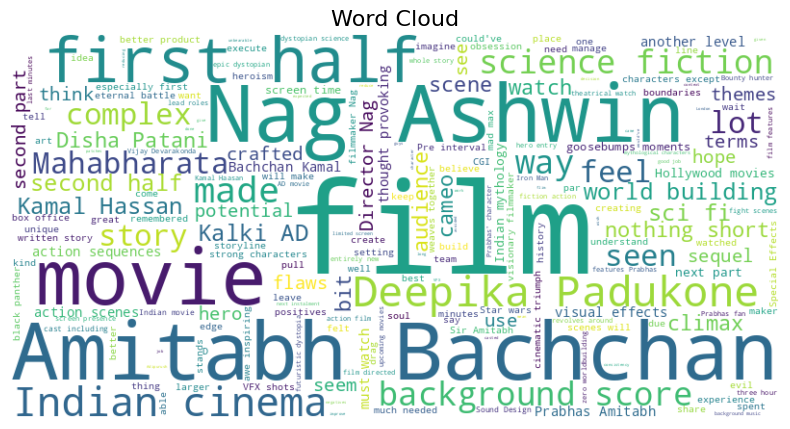

In [81]:
text_data= " ".join(data['Comments'].dropna())
wordcloud = WordCloud(width=800,height=400,background_color='white').generate(text_data)
plt.figure(figsize=(10,5))
plt.imshow(wordcloud,interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud",fontsize=16)
plt.show()